In [21]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

one_anc = np.load("output/PPEEE/t1_280.0_t2_330.0/fidelity_array.npy")
two_anc = np.load("output/Two_Ancillae_PPEEE/t1_280.0_t2_330.0/fidelity_array.npy")
three_anc = np.concat([np.load(f"output/Three_Ancillae_PPEEE_long/fidelity_array{i}.npy") for i in range(1, 6)])


In [27]:
print(one_anc.shape)
print(two_anc.shape)
print(three_anc.shape)

(13615,)
(13521,)
(13561,)


In [22]:
time_scale1 = np.linspace(0, .03 * one_anc.shape[0], one_anc.shape[0])
time_scale2 = np.linspace(0, .03 * two_anc.shape[0], two_anc.shape[0])
time_scale3 = np.linspace(0, .03 * three_anc.shape[0], three_anc.shape[0])

Text(0.5, 0.98, 'Fidelity Comparison of Circuit with Different Numbers of Ancillae')

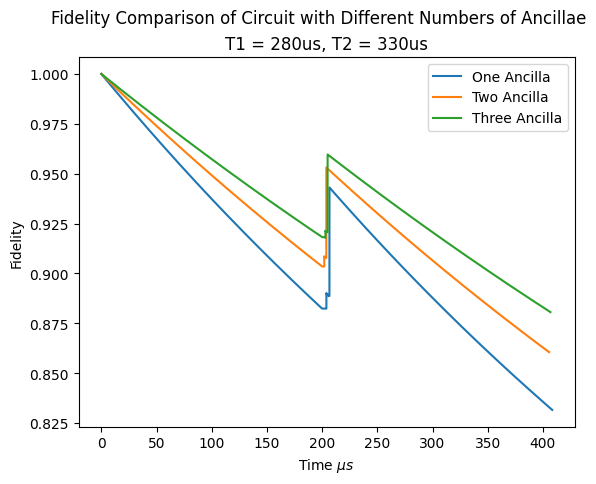

In [29]:
plt.plot(time_scale1,one_anc, label="One Ancilla")
plt.plot(time_scale2,two_anc, label="Two Ancilla")
plt.plot(time_scale3,three_anc, label="Three Ancilla")
plt.legend()
plt.xlabel(r"Time $\mu s$")
plt.ylabel("Fidelity")
plt.title("T1 = 280us, T2 = 330us")
plt.suptitle("Fidelity Comparison of Circuit with Different Numbers of Ancillae")

In [46]:
EEEPP_results = np.load("output/EEEPP/t1_280.0_t2_330.0/fidelity_array.npy")
EEPPE_results = np.load("output/EEPPE/t1_280.0_t2_330.0/fidelity_array.npy")
EPPEE_results = np.load("output/EPPEE/t1_280.0_t2_330.0/fidelity_array.npy")
PPEEE_results = np.load("output/PPEEE/t1_280.0_t2_330.0/fidelity_array.npy")
PEEEP_results = np.load("output/PEEEP/t1_280.0_t2_330.0/fidelity_array.npy")
PEEPE_results = np.load("output/PEEPE/t1_280.0_t2_330.0/fidelity_array.npy")
PEPEE_results = np.load("output/PEPEE/t1_280.0_t2_330.0/fidelity_array.npy")
EPEPE_results = np.load("output/EPEPE/t1_280.0_t2_330.0/fidelity_array.npy")

results = np.array([EEEPP_results, EEPPE_results, EPPEE_results, PPEEE_results, PEEEP_results, PEEPE_results, PEPEE_results, EPEPE_results])

In [47]:
for i in results:
    print(i.shape)

(13780,)
(13780,)
(13780,)
(13780,)
(13780,)
(13780,)
(13780,)
(13780,)


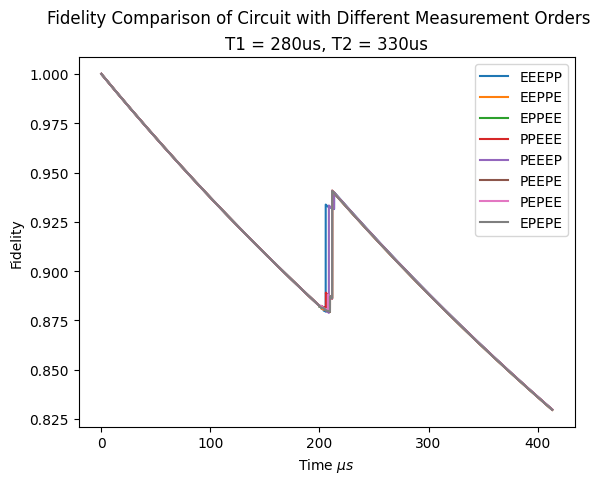

In [56]:
time_scale = np.linspace(0, .03 * results[0].shape[0], results[0].shape[0])
plt.plot(time_scale, results.T, label=["EEEPP", "EEPPE", "EPPEE", "PPEEE", "PEEEP", "PEEPE", "PEPEE", "EPEPE"])
plt.legend()
plt.xlabel(r"Time $\mu s$")
plt.ylabel("Fidelity")
plt.title("T1 = 280us, T2 = 330us") 
plt.suptitle("Fidelity Comparison of Circuit with Different Measurement Orders")
final_fidelities = results[:,-1]

In [ ]:
print(final_fidelities)
print(np.argmin(final_fidelities))
print(np.argmax(final_fidelities))


[0.82983639 0.82965333 0.82976612 0.82985108 0.82981894 0.82971829
 0.8297836  0.82970068]
1
3


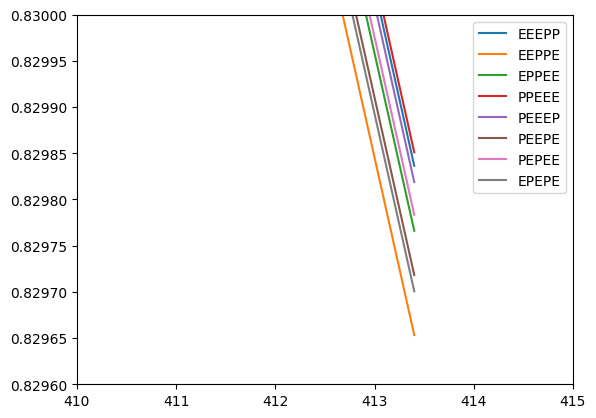

In [68]:
plt.plot(time_scale,results.T, label=["EEEPP", "EEPPE", "EPPEE", "PPEEE", "PEEEP", "PEEPE", "PEPEE", "EPEPE"])
plt.xlim(410,415)
plt.ylim(0.8296,0.830)
plt.legend()

In [19]:
from quantum_logical.experiment_runner import ExperimentRunner
from quantum_logical.gates import hadamard_operator
import qutip as qt

initial_state = qt.tensor([hadamard_operator(3) *qt.basis(3,0)]*3)
fidelities = {4:[], 5:[], 6:[]}
states = {4:[], 5:[], 6:[]}
for num_qudits in range(4, 7):

    initial_setup = qt.tensor(initial_state, *([qt.basis(3,0)]*(num_qudits-3)))
    rho_i = qt.ket2dm(initial_setup)

    trotterer = ExperimentRunner.generate_trotterizer(trotter_dt=.03, T1= 280, T2=330, dim=3, num_qubits=num_qudits)

    id_gate = [qt.tensor([qt.qeye(3) for _ in range(num_qudits)])]

    resulting_states = ExperimentRunner.run_unitary_circuit(trotterer,id_gate,rho_i, [3])

    fidelity = [qt.fidelity(state.ptrace([0,1,2]), qt.ket2dm(initial_state)) for state in resulting_states]
    fidelities[num_qudits] = fidelity

    states[num_qudits] = [state.ptrace([0,1,2]) for state in resulting_states]
 


c:\Users\Warren\Desktop\QuantumLogicalSimulator\.venv\Lib\site-packages\qutip\core\data\expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


time_scale = np.linspace(0, .03*101, 101)

plt.plot(time_scale, fidelities[4], label="4 Qudits")
plt.plot(time_scale, fidelities[5], label="5 Qudits")
plt.plot(time_scale, fidelities[6], label="6 Qudits")

NameError: name 'np' is not defined